<a href="https://colab.research.google.com/github/tanishqsayil-lab/MLEL--Experiment/blob/main/assign7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Feature Names:")
print(data.feature_names)

print("\nFirst 10 Records:")
print(X.head(10))

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 10 Records:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
5 -0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277   
6 -0.045472  0.050680 -0.047163 -0.015999 -0.040096 -0.024800  0.000779   
7  0.063504  0.050680 -0.001895  0.066629  0.090620  0.108914  0.022869   
8  0.041708  0.050680  0.061696 -0.040099 -0.013953  0.006202 -0.028674   
9 -0.070900 -0.044642  0.039062 -0.033213 -0.012577 -0.034508 -0.024993   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (353, 10)
Testing Shape: (89, 10)


In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred_lr)
mse = mean_squared_error(y_test, pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression
MAE : 42.79409467959994
MSE : 2900.193628493482
RMSE: 53.85344583676593
R2 Score: 0.4526027629719195


In [5]:
for a in [0.1, 1, 10]:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)

    pred = ridge.predict(X_test)

    print("Alpha =", a)
    print("R2 Score =", r2_score(y_test, pred))
    print()

Alpha = 0.1
R2 Score = 0.46085219464119265

Alpha = 1
R2 Score = 0.41915292635986545

Alpha = 10
R2 Score = 0.161225867509881



In [6]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("Lasso R2 Score:", r2_score(y_test, pred_lasso))
print("Lasso Coefficients:")
print(lasso.coef_)

Lasso R2 Score: 0.4718547867276227
Lasso Coefficients:
[   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704]


In [7]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

print("ElasticNet R2 Score:", r2_score(y_test, pred_elastic))

ElasticNet R2 Score: 0.09865421116113748


In [8]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": Ridge(alpha=1).fit(X_train, y_train).coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

print(coef_table)

  Feature      Linear       Ridge       Lasso  ElasticNet
0     age   37.904021   45.367377    0.000000   10.830921
1     sex -241.964362  -76.666086 -152.664779   -0.009514
2     bmi  542.428759  291.338832  552.697775   38.906865
3      bp  347.703844  198.995817  303.365158   28.779233
4      s1 -931.488846   -0.530310  -81.365007   10.372007
5      s2  518.062277  -28.577050   -0.000000    7.191892
6      s3  163.419983 -144.511905 -229.255776  -23.510979
7      s4  275.317902  119.260066    0.000000   25.627160
8      s5  736.198859  230.221608  447.919525   35.073745
9      s6   48.670657  112.149830   29.642617   24.071251


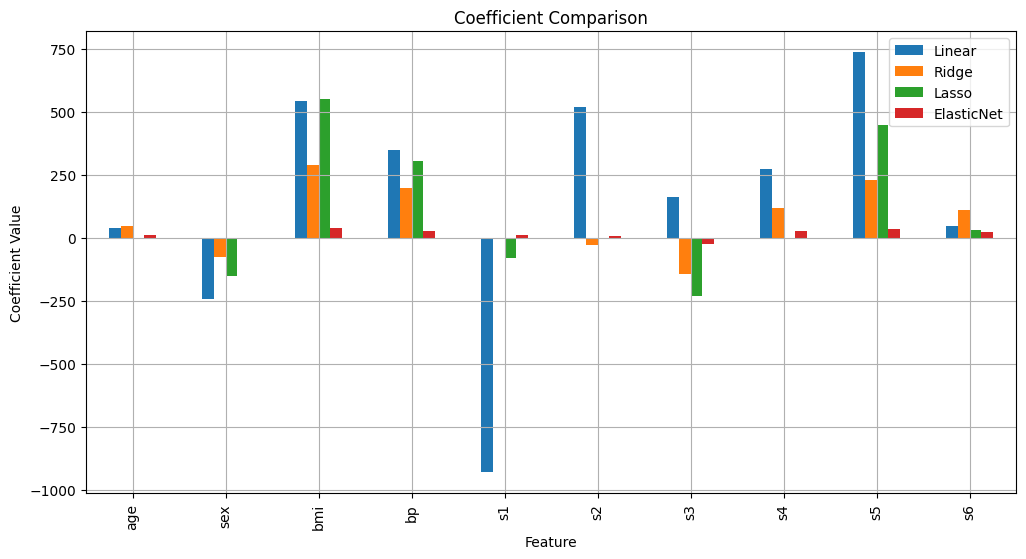

In [9]:
coef_table.set_index("Feature").plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

In [10]:
print("Use Lasso when feature selection is needed.")
print("Use Ridge when all features are useful.")
print("Use ElasticNet when both selection and shrinkage are needed.")

Use Lasso when feature selection is needed.
Use Ridge when all features are useful.
Use ElasticNet when both selection and shrinkage are needed.
